In [96]:
import yfinance as yf
import pandas as pd

symbol='BTC-USD'
period='max'
interval='1d'

def fetch_historical_data_yfinance(symbol, period, interval):
    """Fetch historical stock data from Yahoo Finance."""
    df = yf.download(symbol, period=period, interval=interval)
    
    # Reset the index to include the 'Date' column
    df.reset_index(inplace=True)
    
    # Select relevant columns
    df = df[['Date', 'Open', 'High', 'Low', 'Close']]
    
    # Ensure numerical columns are float
    df[['Open', 'High', 'Low', 'Close']] = df[['Open', 'High', 'Low', 'Close']].astype(float)

    # Save the data to a CSV file with Date as the index
    df.set_index('Date', inplace=True)
    
    return df

# Example usage
if __name__ == "__main__":
    # Fetch historical data for the last 5 years
    df = fetch_historical_data_yfinance(symbol=symbol, period=period, interval=interval)
    print(df)

[*********************100%***********************]  1 of 1 completed

Price               Open          High           Low         Close
Ticker           BTC-USD       BTC-USD       BTC-USD       BTC-USD
Date                                                              
2014-09-17    465.864014    468.174011    452.421997    457.334015
2014-09-18    456.859985    456.859985    413.104004    424.440002
2014-09-19    424.102997    427.834991    384.532013    394.795990
2014-09-20    394.673004    423.295990    389.882996    408.903992
2014-09-21    408.084991    412.425995    393.181000    398.821014
...                  ...           ...           ...           ...
2025-03-16  84333.320312  85051.601562  82017.906250  82579.687500
2025-03-17  82576.335938  84725.328125  82492.156250  84075.687500
2025-03-18  84075.718750  84075.718750  81179.992188  82718.500000
2025-03-19  82718.804688  87021.187500  82569.726562  86854.226562
2025-03-20  86870.867188  87427.312500  85082.132812  85152.492188

[3838 rows x 4 columns]


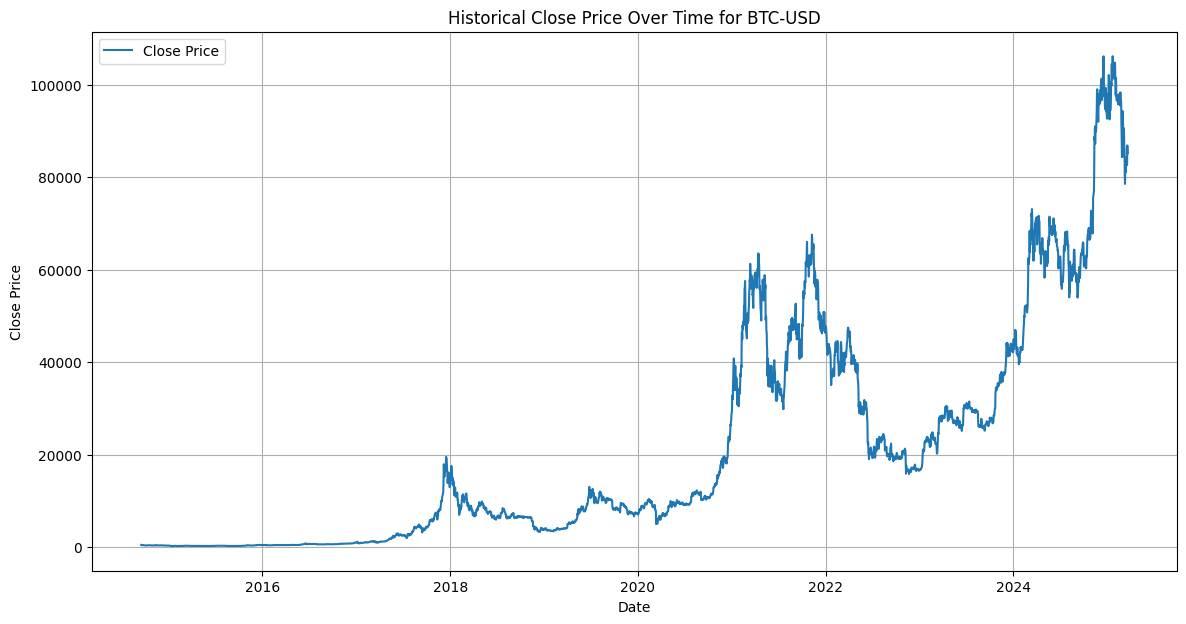

In [97]:
import matplotlib.pyplot as plt

# Plot the 'Close' price over time
plt.figure(figsize=(14, 7))
plt.plot(df.index, df['Close'], label='Close Price')
plt.title(f'Historical Close Price Over Time for {symbol}')
plt.xlabel('Date')
plt.ylabel('Close Price')
plt.legend()
plt.grid(True)
plt.show()

[*********************100%***********************]  1 of 1 completed


Sharpe Ratio: -0.8254
Max Drawdown: -1.3308


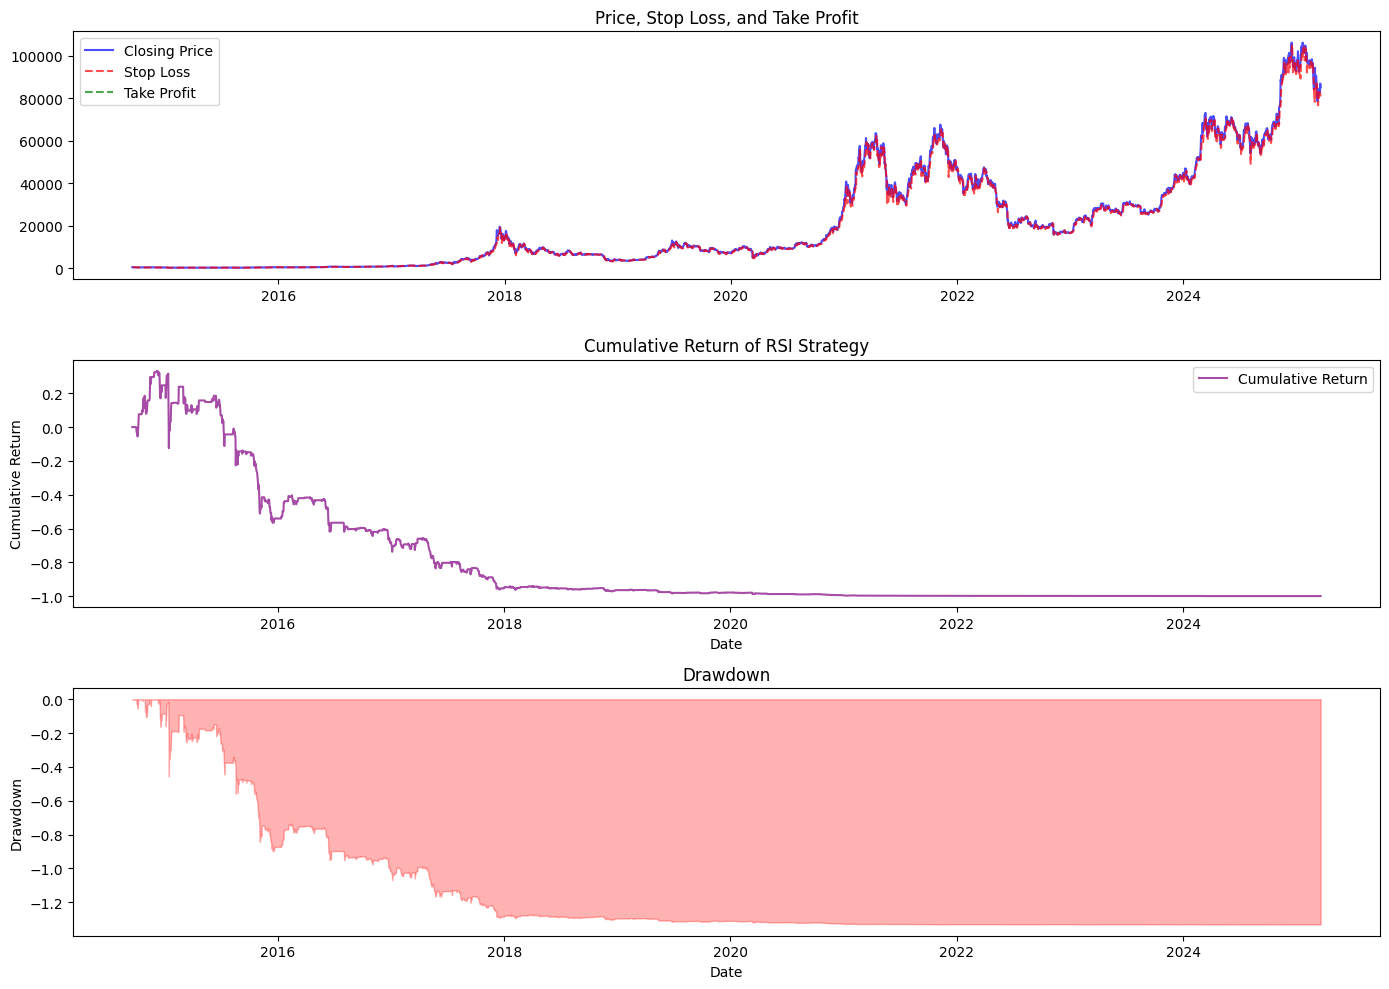


Backtest Results:
Price        Date         Close        rsi     stop_loss take_profit signal  \
Ticker                  BTC-USD                                               
3833   2025-03-16  82579.687500  34.531694  83639.593750         NaN      1   
3834   2025-03-17  84075.687500  46.793585  82017.906250         NaN      0   
3835   2025-03-18  82718.500000  42.789925  82492.156250         NaN      0   
3836   2025-03-19  86854.226562  44.104207  81179.992188         NaN      0   
3837   2025-03-20  85152.492188  42.714654  82569.726562         NaN      0   

Price  cumulative_return portfolio_value slippage_adjusted  drawdown  
Ticker                                                                
3833           -0.998610       13.897734      82587.945469 -1.330430  
3834           -0.998585       14.149503      84084.095069 -1.330405  
3835           -0.998585       14.149503      82726.771850 -1.330405  
3836           -0.998585       14.149503      86862.911985 -1.330405  
3

In [98]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# RSI Calculation
def rsi(df, period=14):
    """ Calculate RSI """
    delta = df['Close'].diff()
    gain = (delta.where(delta > 0, 0)).rolling(window=period).mean()
    loss = (-delta.where(delta < 0, 0)).rolling(window=period).mean()
    rs = gain / loss
    df['rsi'] = 100 - (100 / (1 + rs))
    return df

# Stop Loss and Take Profit Calculation
def calculate_sl_tp(df):
    """ Use the previous low as SL and calculate TP as 1:2 risk-reward """
    
    # Previous candle's low as SL
    df['stop_loss'] = df['Low'].shift(1)  
    
    # Ensure TP is a series, not a DataFrame
    df['take_profit'] = (df['Close'] + 3.333 * (df['Close'] - df['stop_loss'])).iloc[:, 0]

    return df

# RSI Strategy
def rsi_strategy(df, rsi_period=14, overbought=65, oversold=35):
    """ Main RSI trading strategy """
    df = rsi(df, period=rsi_period)
    df = calculate_sl_tp(df)

    df['signal'] = 0  # No trade by default

    # Buy Signal: RSI below oversold
    df.loc[(df['rsi'] < oversold), 'signal'] = 1

    # Sell Signal: RSI above overbought
    df.loc[(df['rsi'] > overbought), 'signal'] = -1

    df['position'] = df['signal'].diff()

    return df

# Backtesting the Strategy
def backtest_strategy(df, initial_capital=10000, slippage=0.0001):
    df = rsi_strategy(df)  # Apply RSI strategy

    # Daily returns
    df['daily_return'] = df['Close'].pct_change()

    # Ensure signal column exists
    if 'signal' not in df.columns:
        raise ValueError("Missing 'signal' column. Ensure signal generation logic is correctly applied.")

    # Strategy returns
    df['strategy_return'] = df['daily_return'] * df['signal'].shift(1)

    # Cumulative returns
    df['cumulative_return'] = (1 + df['strategy_return']).cumprod() - 1

    # Portfolio value
    df['portfolio_value'] = initial_capital * (1 + df['strategy_return']).cumprod()

    # Slippage effect
    df['slippage_adjusted'] = df['Close'] * (1 + slippage)

    # Performance Metrics
    risk_free_rate = 0.01
    df['excess_return'] = df['strategy_return'] - risk_free_rate / 252
    sharpe_ratio = np.sqrt(252) * df['excess_return'].mean() / df['excess_return'].std()

    # Max Drawdown
    df['cumulative_max'] = df['cumulative_return'].cummax()
    df['drawdown'] = df['cumulative_return'] - df['cumulative_max']
    max_drawdown = df['drawdown'].min()

    print(f"Sharpe Ratio: {sharpe_ratio:.4f}")
    print(f"Max Drawdown: {max_drawdown:.4f}")

    # Ensure the 'Date' column is included by resetting the index
    return df.reset_index()[['Date', 'Close', 'rsi', 'stop_loss', 'take_profit', 'signal',
                            'cumulative_return', 'portfolio_value', 'slippage_adjusted', 'drawdown']], sharpe_ratio, max_drawdown


# Plotting Function
def plot_backtest(df):
    plt.figure(figsize=(14, 10))

    # Plot Closing Price, RSI, and SL/TP
    plt.subplot(3, 1, 1)
    plt.plot(df['Date'], df['Close'], label='Closing Price', color='blue', alpha=0.7)
    plt.plot(df['Date'], df['stop_loss'], label='Stop Loss', color='red', linestyle='--', alpha=0.7)
    plt.plot(df['Date'], df['take_profit'], label='Take Profit', color='green', linestyle='--', alpha=0.7)
    plt.title('Price, Stop Loss, and Take Profit')
    plt.legend(loc='best')

    # Cumulative Return
    plt.subplot(3, 1, 2)
    plt.plot(df['Date'], df['cumulative_return'], label='Cumulative Return', color='purple', alpha=0.7)
    plt.title('Cumulative Return of RSI Strategy')
    plt.xlabel('Date')
    plt.ylabel('Cumulative Return')
    plt.legend(loc='best')

    # Drawdown
    plt.subplot(3, 1, 3)
    plt.fill_between(df['Date'], df['drawdown'], color='red', alpha=0.3)
    plt.title('Drawdown')
    plt.xlabel('Date')
    plt.ylabel('Drawdown')

    plt.tight_layout()

    # Display the plot
    plt.show()

# Example usage
if __name__ == "__main__":
    # Fetching Yahoo Finance Data
    symbol = symbol
    period = period
    interval = interval

    # Fetch historical stock data
    df = fetch_historical_data_yfinance(symbol=symbol, period=period, interval=interval)

    # Backtest with fetched data
    backtest_results, sharpe, mdd = backtest_strategy(df)
    plot_url = plot_backtest(backtest_results)

    print("\nBacktest Results:")
    print(backtest_results.tail())
    print(f"\nSharpe Ratio: {sharpe:.4f}")
    print(f"Max Drawdown: {mdd:.4f}")